# 05. 클래스 불균형 처리: SMOTE
## Class Imbalance Handling with SMOTE

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

SECOM 데이터는 전체 샘플 중 Fail이 약 6.6%에 불과한
심각한 클래스 불균형(Class Imbalance)을 가지고 있다.

이전 Baseline 모델링에서 Logistic Regression은 센서 정보를 이용하여
일부 Fail을 검출하였지만, Fail Recall은 약 14.29%에 그쳤으며
실제 Fail 21개 중 18개를 Pass로 잘못 판단하였다.

본 Notebook에서는 SMOTE(Synthetic Minority Over-sampling Technique)를
Training 과정에 적용하여 소수 클래스인 Fail 샘플의 학습 정보를 보강하고,
Baseline Logistic Regression과 성능을 비교한다.

주요 확인 사항은 다음과 같다.

1. SMOTE 적용 후 Fail Recall이 향상되는가?
2. False Negative가 감소하는가?
3. Recall 향상 과정에서 Precision은 어떻게 변화하는가?
4. F1/F2-score와 PR-AUC가 개선되는가?
5. 단순 Accuracy 감소가 실제 모델 성능 저하를 의미하는가?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

SMOTE 적용 효과를 공정하게 비교하기 위해
이전 Baseline 단계와 완전히 동일한 데이터 분할 조건을 사용한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

또한 Feature 제거 기준 역시 Training Data만을 이용하여 계산한다.

따라서 Baseline 모델과 SMOTE 모델의 성능 차이는
데이터 분할 차이가 아니라 클래스 불균형 처리 방법의 차이에 의해
발생하도록 실험 조건을 유지한다.

In [3]:
DATA_PATH = Path("../data/processed/uci-secom.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [4]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(f"\nTrain Fail Rate: {y_train.mean() * 100:.2f}%")
print(f"Test Fail Rate : {y_test.mean() * 100:.2f}%")

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


In [6]:
train_missing_ratio = (
    X_train
    .isna()
    .mean()
    .mul(100)
)

high_missing_features = (
    train_missing_ratio[
        train_missing_ratio >= 40
    ]
    .index
    .tolist()
)

all_missing_features_train = [
    col for col in X_train.columns
    if X_train[col].isna().all()
]

single_value_features_train = [
    col for col in X_train.columns
    if X_train[col].nunique(dropna=True) == 1
]

features_to_remove = sorted(
    set(
        high_missing_features
        + all_missing_features_train
        + single_value_features_train
    )
)

print("Features to remove:", len(features_to_remove))

Features to remove: 148


In [7]:
X_train_filtered = X_train.drop(
    columns=features_to_remove
).copy()

X_test_filtered = X_test.drop(
    columns=features_to_remove
).copy()

print("X_train_filtered:", X_train_filtered.shape)
print("X_test_filtered :", X_test_filtered.shape)

assert X_train_filtered.columns.equals(
    X_test_filtered.columns
)

print("\nFeature filtering validation passed.")

X_train_filtered: (1253, 442)
X_test_filtered : (314, 442)

Feature filtering validation passed.


## 2. SMOTE 적용 전 클래스 분포

SMOTE를 적용하기 전에 Training Data의 Pass/Fail 클래스 분포를 확인한다.

SMOTE는 Test Data에는 적용하지 않으며,
Training Data의 소수 클래스인 Fail에 대해서만 합성 샘플을 생성한다.

Test Data는 실제 데이터 분포를 그대로 유지하여
최종 모델의 일반화 성능을 평가하는 데 사용한다.

In [8]:
train_class_counts = (
    y_train
    .value_counts()
    .sort_index()
)

print("Training class distribution:")
print(train_class_counts)

print("\nPass samples:", (y_train == 0).sum())
print("Fail samples:", (y_train == 1).sum())

Training class distribution:
Pass/Fail
0    1170
1      83
Name: count, dtype: int64

Pass samples: 1170
Fail samples: 83


In [9]:
preview_imputer = SimpleImputer(
    strategy="median"
)

preview_scaler = StandardScaler()

X_train_preview = preview_imputer.fit_transform(
    X_train_filtered
)

X_train_preview = preview_scaler.fit_transform(
    X_train_preview
)

preview_smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42
)

X_train_resampled_preview, y_train_resampled_preview = (
    preview_smote.fit_resample(
        X_train_preview,
        y_train
    )
)

In [10]:
before_smote = (
    y_train
    .value_counts()
    .sort_index()
)

after_smote = (
    pd.Series(y_train_resampled_preview)
    .value_counts()
    .sort_index()
)

print("Before SMOTE")
print(before_smote)

print("\nAfter SMOTE")
print(after_smote)

Before SMOTE
Pass/Fail
0    1170
1      83
Name: count, dtype: int64

After SMOTE
Pass/Fail
0    1170
1    1170
Name: count, dtype: int64


### SMOTE 적용 의미

기존 Training Data에서는 Fail 샘플이 Pass 샘플보다 매우 적기 때문에
일반적인 분류 모델은 다수 클래스인 Pass를 중심으로 학습될 가능성이 있다.

SMOTE는 기존 Fail 샘플을 단순 복제하는 대신
주변 소수 클래스 샘플 간 관계를 이용하여 새로운 합성 샘플을 생성한다.

이를 통해 모델이 Fail 클래스의 결정 경계를 학습할 수 있는
추가적인 정보를 제공하는 것을 목표로 한다.

단, 생성된 데이터는 실제 측정된 새로운 Wafer가 아니라
기존 데이터로부터 생성된 합성 샘플이라는 점에 주의해야 한다.

In [11]:
class_distribution = pd.DataFrame({
    "Before SMOTE": [
        before_smote.get(0, 0),
        before_smote.get(1, 0)
    ],
    "After SMOTE": [
        after_smote.get(0, 0),
        after_smote.get(1, 0)
    ]
}, index=["Pass", "Fail"])

class_distribution

,Before SMOTE,After SMOTE
Pass,1170,1170
Fail,83,1170


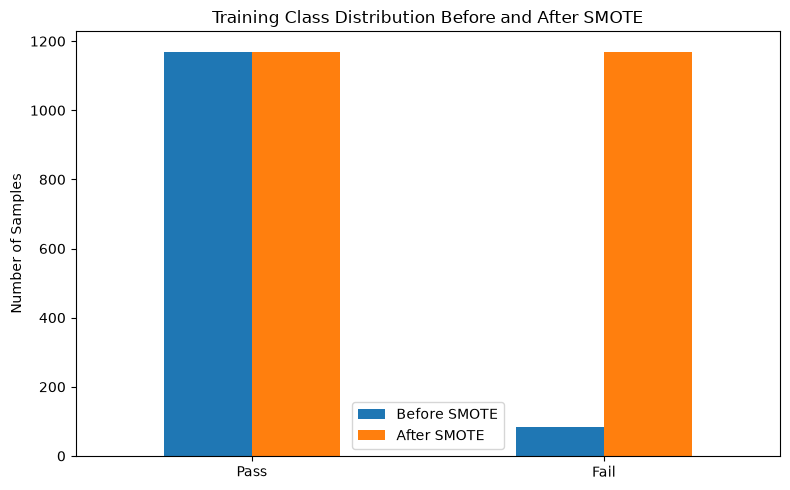

Saved to: ..\results\figures\smote_class_distribution.png


In [12]:
class_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Number of Samples")
plt.title("Training Class Distribution Before and After SMOTE")
plt.xticks(rotation=0)

plt.tight_layout()

SMOTE_DISTRIBUTION_PATH = Path(
    "../results/figures/smote_class_distribution.png"
)

plt.savefig(
    SMOTE_DISTRIBUTION_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", SMOTE_DISTRIBUTION_PATH)

## 3. SMOTE + Logistic Regression Pipeline

실제 모델 학습에서는 SMOTE를 사전에 적용한 데이터를 따로 생성하지 않고
전처리와 SMOTE를 하나의 Pipeline으로 구성한다.

Pipeline의 순서는 다음과 같다.

1. Median Imputation
2. Standard Scaling
3. SMOTE
4. Logistic Regression

SMOTE는 최근접 이웃을 이용하여 합성 샘플을 생성하므로,
본 실험에서는 센서 변수 간 Scale 차이가 거리 계산에 미치는 영향을 줄이기 위해
Scaling 이후 SMOTE를 적용한다.

중요한 점은 SMOTE가 Training 과정에서만 수행된다는 것이다.

Test Data에는 어떠한 합성 샘플도 생성하지 않으며
원래의 클래스 분포를 그대로 유지한다.

In [13]:
smote_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "smote",
        SMOTE(
            sampling_strategy=1.0,
            random_state=42
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

print(smote_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42, sampling_strategy=1.0)),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])


In [14]:
smote_pipeline.fit(
    X_train_filtered,
    y_train
)

print(
    "SMOTE Logistic Regression training completed."
)

SMOTE Logistic Regression training completed.


In [15]:
model_is_fitted = hasattr(
    smote_pipeline.named_steps["model"],
    "coef_"
)

print(
    "Model fitted:",
    model_is_fitted
)

Model fitted: True


In [16]:
smote_pred = smote_pipeline.predict(
    X_test_filtered
)

smote_prob = smote_pipeline.predict_proba(
    X_test_filtered
)[:, 1]

print("Prediction completed.")
print("Predictions:", len(smote_pred))

Prediction completed.
Predictions: 314


In [17]:
print("SMOTE Logistic predicted classes:")

print(
    pd.Series(smote_pred)
    .value_counts()
    .sort_index()
)

SMOTE Logistic predicted classes:
0    275
1     39
Name: count, dtype: int64


In [18]:
smote_accuracy = accuracy_score(
    y_test,
    smote_pred
)

smote_precision = precision_score(
    y_test,
    smote_pred,
    zero_division=0
)

smote_recall = recall_score(
    y_test,
    smote_pred,
    zero_division=0
)

smote_f1 = f1_score(
    y_test,
    smote_pred,
    zero_division=0
)

smote_f2 = fbeta_score(
    y_test,
    smote_pred,
    beta=2,
    zero_division=0
)

smote_pr_auc = average_precision_score(
    y_test,
    smote_prob
)

smote_roc_auc = roc_auc_score(
    y_test,
    smote_prob
)

print(f"Accuracy  : {smote_accuracy:.4f}")
print(f"Precision : {smote_precision:.4f}")
print(f"Recall    : {smote_recall:.4f}")
print(f"F1-score  : {smote_f1:.4f}")
print(f"F2-score  : {smote_f2:.4f}")
print(f"PR-AUC    : {smote_pr_auc:.4f}")
print(f"ROC-AUC   : {smote_roc_auc:.4f}")

Accuracy  : 0.8280
Precision : 0.0769
Recall    : 0.1429
F1-score  : 0.1000
F2-score  : 0.1220
PR-AUC    : 0.1187
ROC-AUC   : 0.6166


In [19]:
print(
    classification_report(
        y_test,
        smote_pred,
        target_names=[
            "Pass",
            "Fail"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Pass       0.93      0.88      0.90       293
        Fail       0.08      0.14      0.10        21

    accuracy                           0.83       314
   macro avg       0.51      0.51      0.50       314
weighted avg       0.88      0.83      0.85       314



In [20]:
smote_cm = confusion_matrix(
    y_test,
    smote_pred
)

print(smote_cm)

[[257  36]
 [ 18   3]]


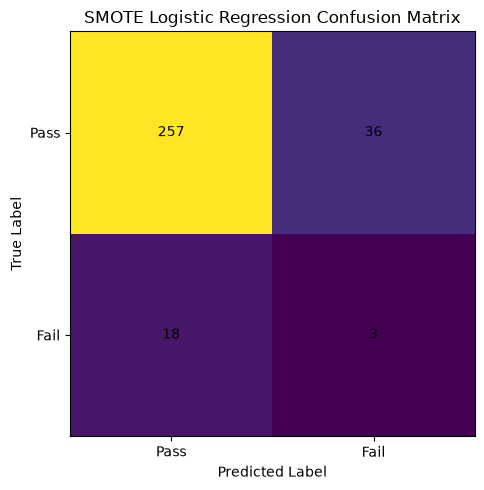

Saved to: ..\results\figures\smote_logistic_confusion_matrix.png


In [21]:
SMOTE_CM_PATH = Path(
    "../results/figures/smote_logistic_confusion_matrix.png"
)

plt.figure(figsize=(6, 5))

plt.imshow(smote_cm)

plt.title("SMOTE Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Pass", "Fail"]
)

plt.yticks(
    [0, 1],
    ["Pass", "Fail"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            smote_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    SMOTE_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", SMOTE_CM_PATH)

In [22]:
BASELINE_RESULT_PATH = Path(
    "../results/metrics/baseline_model_results.csv"
)

baseline_results = pd.read_csv(
    BASELINE_RESULT_PATH
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,Dummy Classifier,0.933121,0.000,0.000000,0.000000,0.000000,0.066879,0.50000
1,Logistic Regression,0.875796,0.125,0.142857,0.133333,0.138889,0.119017,0.62051


In [23]:
smote_tn, smote_fp, smote_fn, smote_tp = (
    smote_cm.ravel()
)

smote_result = pd.DataFrame({
    "Model": [
        "Logistic Regression + SMOTE"
    ],

    "Accuracy": [
        smote_accuracy
    ],

    "Precision": [
        smote_precision
    ],

    "Recall": [
        smote_recall
    ],

    "F1": [
        smote_f1
    ],

    "F2": [
        smote_f2
    ],

    "PR-AUC": [
        smote_pr_auc
    ],

    "ROC-AUC": [
        smote_roc_auc
    ],

    "False Negatives": [
        smote_fn
    ],

    "True Positives": [
        smote_tp
    ]
})

smote_result.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives
0,Logistic Regression + SMOTE,0.828,0.0769,0.1429,0.1,0.122,0.1187,0.6166,18,3


In [24]:
model_comparison = pd.concat(
    [
        baseline_results,
        smote_result
    ],
    ignore_index=True
)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives
0,Dummy Classifier,0.9331,0.0000,0.0000,0.0000,0.0000,0.0669,0.5000,NaN,NaN
1,Logistic Regression,0.8758,0.1250,0.1429,0.1333,0.1389,0.1190,0.6205,NaN,NaN
2,Logistic Regression + SMOTE,0.8280,0.0769,0.1429,0.1000,0.1220,0.1187,0.6166,18.0,3.0


In [25]:
fail_detection_comparison = (
    model_comparison[
        [
            "Model",
            "Precision",
            "Recall",
            "F1",
            "F2",
            "PR-AUC",
            "False Negatives",
            "True Positives"
        ]
    ]
)

fail_detection_comparison.round(4)

,Model,Precision,Recall,F1,F2,PR-AUC,False Negatives,True Positives
0,Dummy Classifier,0.0000,0.0000,0.0000,0.0000,0.0669,NaN,NaN
1,Logistic Regression,0.1250,0.1429,0.1333,0.1389,0.1190,NaN,NaN
2,Logistic Regression + SMOTE,0.0769,0.1429,0.1000,0.1220,0.1187,18.0,3.0


In [26]:
SMOTE_RESULT_PATH = Path(
    "../results/metrics/baseline_vs_smote_results.csv"
)

model_comparison.to_csv(
    SMOTE_RESULT_PATH,
    index=False
)

print("Saved to:", SMOTE_RESULT_PATH)
print("File exists:", SMOTE_RESULT_PATH.exists())

Saved to: ..\results\metrics\baseline_vs_smote_results.csv
File exists: True


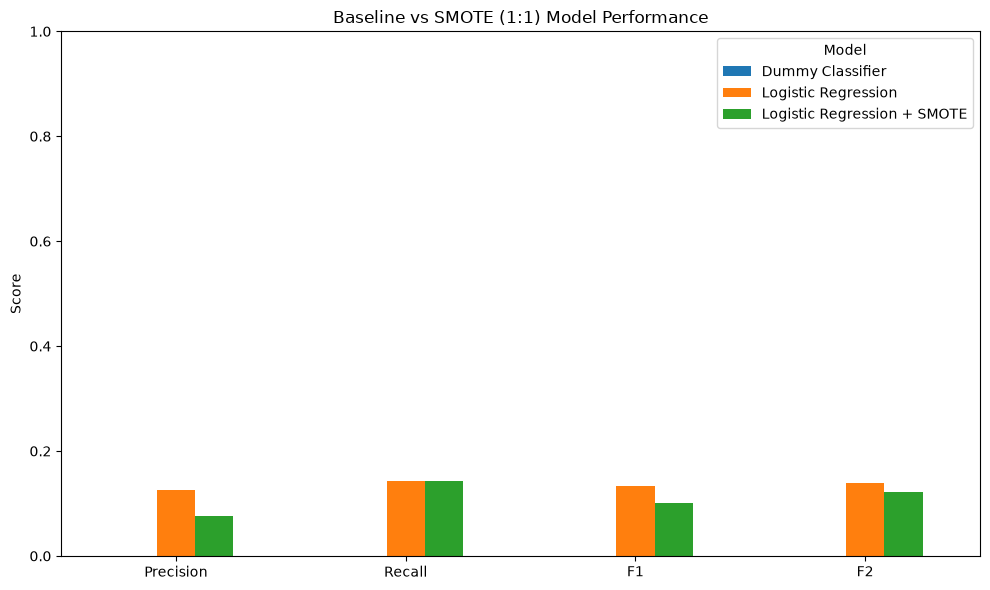

Saved to: ..\results\figures\baseline_vs_smote_comparison.png


In [29]:
comparison_metrics = [
    "Precision",
    "Recall",
    "F1",
    "F2"
]

model_comparison.set_index("Model")[
    comparison_metrics
].T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")

plt.title(
    "Baseline vs SMOTE (1:1) Model Performance"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()

SMOTE_COMPARISON_PATH = Path(
    "../results/figures/baseline_vs_smote_comparison.png"
)

plt.savefig(
    SMOTE_COMPARISON_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    SMOTE_COMPARISON_PATH
)

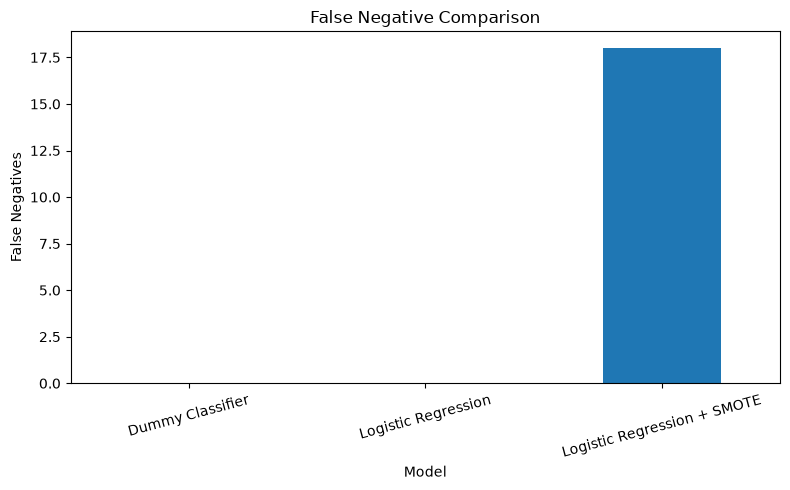

In [28]:
fn_comparison = (
    model_comparison[
        [
            "Model",
            "False Negatives"
        ]
    ]
    .set_index("Model")
)

fn_comparison.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.ylabel("False Negatives")
plt.title("False Negative Comparison")

plt.xticks(rotation=15)

plt.tight_layout()

FN_FIGURE_PATH = Path(
    "../results/figures/false_negative_comparison.png"
)

plt.savefig(
    FN_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. SMOTE 적용 결과 평가

SMOTE 적용 효과는 단순 Accuracy 변화가 아니라
Fail 검출 성능을 중심으로 평가한다.

특히 Baseline Logistic Regression과 비교하여 다음을 확인한다.

- Fail Recall 변화
- False Negative 변화
- True Positive 변화
- Precision 변화
- F1/F2-score 변화
- PR-AUC 변화

SMOTE 적용 후 Recall이 증가하더라도
False Positive가 크게 증가하여 Precision이 지나치게 낮아질 수 있다.

따라서 하나의 지표만을 기준으로 모델 개선 여부를 판단하지 않고,
Fail을 더 많이 검출하면서도 오탐 증가가 어느 정도인지 함께 평가한다.

## 5. SMOTE 적용 종합 결과 (SMOTE Evaluation Summary)

본 단계에서는 SECOM 데이터의 심각한 클래스 불균형을 완화하기 위해
Training Data에 SMOTE를 적용하고 Baseline Logistic Regression과 성능을 비교하였다.

### 1. Training Data 클래스 분포 변화

SMOTE 적용 전 Training Data의 클래스 분포는 다음과 같았다.

- Pass: 1,170개
- Fail: 83개

Fail 클래스의 샘플 수가 매우 적어 모델이 다수 클래스인 Pass 중심으로
학습될 가능성이 존재하였다.

본 실험에서는 `sampling_strategy=1.0`을 적용하여
Training Data의 클래스 비율을 1:1로 조정하였다.

SMOTE 적용 후:

- Pass: 1,170개
- Fail: 1,170개

로 클래스 수가 균형을 이루었다.

단, 추가된 Fail 데이터는 실제 제조 과정에서 측정된 새로운 샘플이 아니라
기존 Fail 샘플의 이웃 관계를 기반으로 생성된 합성 데이터이다.


### 2. Baseline Logistic Regression과 비교

Baseline Logistic Regression의 주요 성능은 다음과 같았다.

- Accuracy: 87.58%
- Precision: 12.50%
- Recall: 14.29%
- F1-score: 13.33%
- F2-score: 13.89%
- PR-AUC: 0.1190
- ROC-AUC: 0.6205

SMOTE 적용 후 Logistic Regression의 성능은 다음과 같았다.

- Accuracy: 82.80%
- Precision: 7.69%
- Recall: 14.29%
- F1-score: 10.00%
- F2-score: 12.20%
- PR-AUC: 0.1187
- ROC-AUC: 0.6166


### 3. Fail 검출 성능 비교

Baseline Logistic Regression의 Confusion Matrix는 다음과 같았다.

- True Positive: 3개
- False Negative: 18개
- False Positive: 21개
- True Negative: 272개

SMOTE 적용 후에는:

- True Positive: 3개
- False Negative: 18개
- False Positive: 36개
- True Negative: 257개

로 나타났다.

SMOTE 적용 후에도 실제 Fail 21개 중 검출된 샘플은 3개로 동일하였으며,
Fail Recall 역시 **14.29%로 개선되지 않았다.**

반면 False Positive는 21개에서 36개로 증가하였다.

즉 본 실험에서 SMOTE는 추가적인 Fail을 검출하지 못한 상태에서
정상 샘플을 Fail로 잘못 판단하는 오탐만 증가시켰다.


### 4. 결과 해석

본 결과는 SMOTE를 적용하는 것만으로
클래스 불균형 문제를 해결할 수 있는 것은 아님을 보여준다.

현재 Training Data에는 실제 Fail 샘플이 83개뿐인 반면,
전처리 후에도 442개의 센서 변수가 존재한다.

따라서 고차원 공간에서 제한된 Fail 샘플을 이용하여 생성된
합성 데이터가 실제 Fail 패턴을 충분히 대표하지 못했을 가능성이 있다.

또한 본 실험에서는 Fail 클래스를 Pass와 동일한 수까지 증가시키는
1:1 Oversampling을 적용하였기 때문에,
Oversampling 수준이 과도했을 가능성도 고려할 필요가 있다.

따라서 이번 결과만으로 SMOTE 자체가 효과가 없다고 일반화하지 않고,

**현재 Feature 구성 + Logistic Regression + SMOTE 1:1 설정에서는
Fail 검출 성능의 개선이 확인되지 않았다**

고 해석한다.


### 5. 모델링 관점의 시사점

본 실험을 통해 단순히 클래스 개수를 동일하게 만드는 것보다
실제 Fail을 구분할 수 있는 유효한 Feature를 확보하는 것이
중요할 가능성을 확인하였다.

따라서 다음 단계에서는 고차원 센서 변수 중
불량 예측에 유용한 Feature를 선별하는 Feature Selection을 수행한다.

Feature 수를 줄인 이후에는 필요에 따라 다음 방법을 추가적으로 비교할 수 있다.

- 부분적인 SMOTE Oversampling
- `sampling_strategy` 조정
- `k_neighbors` 조정
- Class Weight
- Decision Threshold 조정
- 비선형 모델 적용


## 다음 단계: Feature Selection

다음 Notebook에서는 현재 442개의 센서 변수 중
예측에 상대적으로 유용한 Feature를 선별한다.

Feature Selection을 통해 다음 효과를 기대한다.

1. 불필요하거나 중복된 센서 변수 감소
2. 고차원 데이터 문제 완화
3. 모델의 과적합 가능성 감소
4. Fail과 관련된 주요 패턴 학습 강화
5. 이후 XGBoost 등 비선형 모델의 효율적인 학습

Feature Selection 과정 역시 Data Leakage를 방지하기 위해
Training Data만을 이용하여 수행한다.